# 03 — Imbalanced learning

**Estimated time:** 100–140 minutes  
**Prerequisites:** notebooks 00–02; cross-validation, metrics, and pipelines.  
**Depends on:** the split contract from notebook 00 and feature pipeline from notebook 02.

## Learning objectives

- Compare class weights, thresholds, under/oversampling, SMOTE, and SMOTENC.
- Resample only within CV training folds using `imblearn.pipeline.Pipeline`.
- Evaluate classification behavior, probability quality, and business cost separately.
- Recognize when synthetic interpolation is semantically invalid.


In [18]:
import hashlib, json, os, platform, random, warnings
from pathlib import Path
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
# Known interoperability/UI warnings do not affect predictions or notebook execution.
warnings.filterwarnings("ignore", message="X does not have valid feature names, but LGBMClassifier")
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", category=FutureWarning, message="'force_all_finite' was renamed to 'ensure_all_finite'.*")
warnings.filterwarnings("ignore", category=FutureWarning, message="`BaseEstimator._check_n_features` is deprecated.*")
warnings.filterwarnings("ignore", category=FutureWarning, message="`BaseEstimator._check_feature_names` is deprecated.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (balanced_accuracy_score, brier_score_loss, confusion_matrix,
                             f1_score, log_loss, precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
TARGET = "y"
LEAKAGE_COLUMNS = ["duration"]

def project_root():
    '''Return the course root when present, otherwise the notebook directory.'''
    # Return the course root when present, otherwise the notebook's directory.
    return ROOT

def set_seed(seed=SEED):
    '''Seed Python and NumPy RNGs for reproducible notebook runs.'''
    random.seed(seed)
    np.random.seed(seed)

def fast_mode():
    '''Report whether notebooks should use the reduced fast-mode sample.'''
    # Set FAST_MODE=0 for full-size experiments; laptop mode is the default.
    return os.getenv("FAST_MODE", "1").lower() not in {"0", "false", "no"}

def bank_data_path():
    '''Locate the bundled Bank Marketing CSV file.'''
    # The course ships with a local dataset; notebooks never access the network.
    path = project_root() / "data" / "raw" / "bank-full.csv"
    if not path.is_file():
        raise FileNotFoundError(
            f"Expected the bundled Bank Marketing data at {path}. "
            "Run the notebook from the course root or place bank-full.csv there."
        )
    return path

def file_sha256(path):
    '''Compute the SHA-256 digest of a local file.'''
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()

def load_bank_data(include_duration=False):
    '''Load the Bank Marketing dataset and drop leakage columns by default.'''
    # Load the data, encode y, and exclude post-call duration by default.
    frame = pd.read_csv(bank_data_path(), sep=";")
    frame[TARGET] = frame[TARGET].map({"no": 0, "yes": 1}).astype("int8")
    if not include_duration:
        frame = frame.drop(columns=LEAKAGE_COLUMNS)
    return frame

def stratified_sample(frame, n, seed=SEED):
    '''Draw a label-preserving sample from a classified dataset.'''
    if n >= len(frame):
        return frame.copy()
    fractions = frame[TARGET].value_counts(normalize=True)
    counts = (fractions * n).round().astype(int)
    counts.iloc[0] += n - counts.sum()
    parts = [group.sample(n=min(counts.loc[label], len(group)),
                          random_state=seed + int(label))
             for label, group in frame.groupby(TARGET)]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

def make_splits(frame=None, reduced=None):
    '''Create deterministic stratified train, validation, and test splits.'''
    # Deterministic stratified 60/20/20 split; test stays sealed until notebook 09.
    from sklearn.model_selection import train_test_split
    frame = load_bank_data() if frame is None else frame
    train_val, test = train_test_split(
        frame, test_size=0.20, stratify=frame[TARGET], random_state=SEED)
    train, validation = train_test_split(
        train_val, test_size=0.25, stratify=train_val[TARGET], random_state=SEED)
    reduced = fast_mode() if reduced is None else reduced
    if reduced:
        train = stratified_sample(train, 12_000)
        validation = stratified_sample(validation, 4_000, SEED + 1)
        test = stratified_sample(test, 4_000, SEED + 2)
    return tuple(part.reset_index(drop=True) for part in (train, validation, test))

def split_xy(frame):
    '''Separate a frame into feature matrix and target vector.'''
    return frame.drop(columns=TARGET), frame[TARGET]

def feature_groups(frame):
    '''Identify numeric and categorical feature columns.'''
    features = frame.drop(columns=[TARGET], errors="ignore")
    categorical = features.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numerical = features.select_dtypes(include=np.number).columns.tolist()
    return numerical, categorical

def make_preprocessor(frame, scale_numeric=True):
    '''Build the preprocessing pipeline for numeric and categorical features.'''
    # Preprocessing is fitted only inside the enclosing training/CV pipeline.
    numerical, categorical = feature_groups(frame)
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                 min_frequency=10, sparse_output=True)),
    ])
    return ColumnTransformer([
        ("numeric", Pipeline(numeric_steps), numerical),
        ("categorical", categorical_pipe, categorical),
    ], sparse_threshold=0.3)

def classification_metrics(y_true, probability, threshold=0.5):
    '''Compute ranking and threshold-based classification metrics.'''
    prediction = np.asarray(probability) >= threshold
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {"log_loss": log_loss(y_true, probability),
            "brier_score": brier_score_loss(y_true, probability),
            "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
            "f1": f1_score(y_true, prediction, zero_division=0),
            "precision": precision_score(y_true, prediction, zero_division=0),
            "recall": recall_score(y_true, prediction, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "cost": float(fp + 5 * fn)}

def threshold_table(y_true, probability, thresholds=None):
    '''Evaluate classification metrics across a list of decision thresholds.'''
    thresholds = np.linspace(0.05, 0.80, 76) if thresholds is None else thresholds
    return pd.DataFrame([{"threshold": float(t),
                          **classification_metrics(y_true, probability, float(t))}
                         for t in thresholds])

def add_domain_features(frame):
    '''Create domain-inspired features for the Bank Marketing dataset.'''
    result = frame.copy()
    result["was_previously_contacted"] = (result["pdays"] != -1).astype("int8")
    result["pdays_clean"] = result["pdays"].replace(-1, np.nan)
    result["contact_pressure"] = result["campaign"] / (1 + result["previous"])
    result["balance_per_age"] = result["balance"] / result["age"].clip(lower=18)
    result["age_band"] = pd.cut(result["age"], bins=[0, 29, 39, 49, 59, np.inf],
                                labels=["<30", "30s", "40s", "50s", "60+"]).astype("object")
    return result.drop(columns=["pdays"])

def environment_metadata():
    '''Collect runtime metadata for experiment tracking.'''
    import sklearn
    return {"python": platform.python_version(), "platform": platform.platform(),
            "numpy": np.__version__, "pandas": pd.__version__,
            "scikit_learn": sklearn.__version__}

def write_json(data, path):
    '''Serialize structured data to a JSON file on disk.'''
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")

set_seed(SEED)
FAST_MODE = fast_mode()
CV_FOLDS = 3 if FAST_MODE else 5
BRAND_COLOR = "#2a9d8f"
ACCENT_COLOR = "#e76f51"
sns.set_theme(style="whitegrid", context="notebook", palette=[BRAND_COLOR, ACCENT_COLOR, "#264653", "#f4a261"])
plt.rcParams.update({
    "axes.facecolor": "#fcfcfc",
    "figure.facecolor": "white",
    "axes.edgecolor": "#d9d9d9",
    "grid.color": "#e8e8e8",
    "grid.linewidth": 0.8,
    "axes.titleweight": "bold",
    "axes.labelweight": "normal",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_columns", 30)
print({"FAST_MODE": FAST_MODE, "CV_FOLDS": CV_FOLDS, "seed": SEED})


{'FAST_MODE': True, 'CV_FOLDS': 3, 'seed': 42}


In [19]:
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.metrics import make_scorer
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC
from imblearn.under_sampling import RandomUnderSampler

development, validation, _sealed_test = make_splits(load_bank_data(), reduced=FAST_MODE)
X_dev, y_dev = split_xy(development)
X_val, y_val = split_xy(validation)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
class_audit = pd.DataFrame({
    "development": y_dev.value_counts().sort_index(),
    "validation": y_val.value_counts().sort_index(),
}).rename(index={0: "no", 1: "yes"})
class_audit.loc[:, "development_rate"] = class_audit["development"] / len(y_dev)
class_audit.loc[:, "validation_rate"] = class_audit["validation"] / len(y_val)
display(class_audit)
print(f"Positive-class prevalence: {y_dev.mean():.4f}")


,development,validation,development_rate,validation_rate
y,,,,
no,10596,3532,0.883,0.883
yes,1404,468,0.117,0.117


Positive-class prevalence: 0.1170


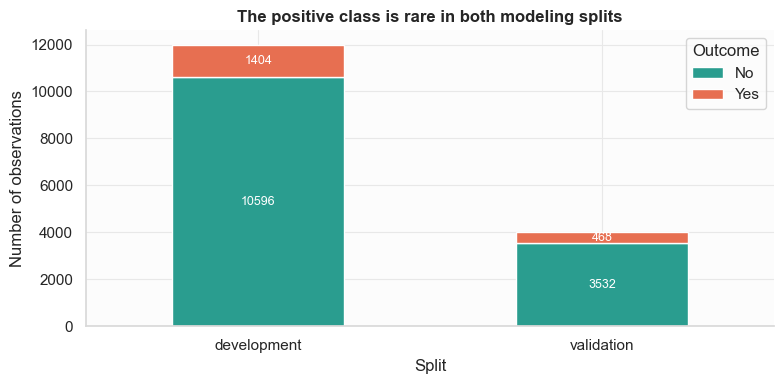

In [20]:
class_plot = class_audit[["development", "validation"]].T
ax = class_plot.plot(kind="bar", stacked=True, figsize=(8, 4),
                     color=[BRAND_COLOR, ACCENT_COLOR])
ax.set(title="The positive class is rare in both modeling splits",
       xlabel="Split", ylabel="Number of observations")
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, label_type="center", color="white", fontsize=9)
ax.legend(title="Outcome", labels=["No", "Yes"])
plt.tight_layout()


## Why sampler placement matters

Resampling before cross-validation lets synthetic or duplicated observations influence both
training and validation folds. That is leakage. An imbalanced-learn pipeline calls the sampler
only during `fit`, so each fold's validation rows remain untouched.

SMOTE interpolates between minority neighbors. Applied after one-hot encoding, it can create
fractional pseudo-categories. That may run numerically but is semantically dubious. We include it
as a cautionary comparison and use SMOTENC for mixed data.


In [21]:
preprocessors = {name: make_preprocessor(development) for name in
                 ["dummy", "plain", "weighted", "under", "over", "smote"]}
candidates = {
    "dummy_prior": SkPipeline([("preprocess", preprocessors["dummy"]),
                                ("model", DummyClassifier(strategy="prior"))]),
    "plain": SkPipeline([("preprocess", preprocessors["plain"]),
                         ("model", LogisticRegression(max_iter=1200, random_state=SEED))]),
    "class_weight": SkPipeline([("preprocess", preprocessors["weighted"]),
                                ("model", LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED))]),
    "random_under": ImbPipeline([("preprocess", preprocessors["under"]),
                                 ("sample", RandomUnderSampler(random_state=SEED)),
                                 ("model", LogisticRegression(max_iter=1200, random_state=SEED))]),
    "random_over": ImbPipeline([("preprocess", preprocessors["over"]),
                                ("sample", RandomOverSampler(random_state=SEED)),
                                ("model", LogisticRegression(max_iter=1200, random_state=SEED))]),
    "SMOTE_after_onehot_caution": ImbPipeline([("preprocess", preprocessors["smote"]),
                                               ("sample", SMOTE(random_state=SEED)),
                                               ("model", LogisticRegression(max_iter=1200, random_state=SEED))]),
}


In [22]:
scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
    "log_loss": "neg_log_loss",
}
cv_rows = []
for name, estimator in candidates.items():
    scores = cross_validate(estimator, X_dev, y_dev, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"method": name}
    for metric in scoring:
        values = scores[f"test_{metric}"] * (-1 if metric == "log_loss" else 1)
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std(ddof=1)
    cv_rows.append(row)
cv_comparison = pd.DataFrame(cv_rows).set_index("method")
cv_comparison.sort_values("balanced_accuracy_mean", ascending=False).round(4)


/Users/soroush/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/soroush/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/soroush/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/soroush/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/soroush/Library/Python/3.9/lib/python/site-packages/s

,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,log_loss_mean,log_loss_std
method,,,,,,,,,,
class_weight,0.6895,0.0141,0.2507,0.0111,0.6275,0.0246,0.3583,0.0148,0.5668,0.0024
random_over,0.6879,0.0144,0.2488,0.0117,0.6268,0.0224,0.3561,0.0156,0.5685,0.0008
random_under,0.6853,0.0153,0.2372,0.0181,0.6481,0.0069,0.3471,0.0200,0.5773,0.0041
SMOTE_after_onehot_caution,0.6792,0.0171,0.2396,0.0105,0.6182,0.0338,0.3453,0.0161,0.5624,0.0035
plain,0.5628,0.0017,0.5944,0.0235,0.1382,0.0049,0.2241,0.0051,0.3076,0.0035
dummy_prior,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3609,0.0000


Resampling changes the class prior seen during fitting, so raw probabilities can become badly
calibrated even when recall improves. Class weighting has a similar effect on the loss. Threshold
metrics must therefore be read alongside log loss and calibration.

## SMOTENC: preserve categorical semantics

The preprocessing below outputs numeric columns first and ordinal-encoded categories second.
`SMOTENC` is told exactly which intermediate columns are categorical. After sampling, numeric
columns are scaled and categorical codes are one-hot encoded. This last step matters: ordinal
codes are identifiers, so feeding the codes directly to logistic regression would impose a false
distance and ordering between categories.


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

numerical, categorical = feature_groups(development)
ordinal_preprocess = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), numerical),
    ("categorical", SkPipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ]), categorical),
], sparse_threshold=0)
numerical_indices = list(range(len(numerical)))
categorical_indices = list(range(len(numerical), len(numerical) + len(categorical)))
post_smotenc = ColumnTransformer([
    ("numeric", StandardScaler(), numerical_indices),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
     categorical_indices),
], sparse_threshold=0)
smotenc_model = ImbPipeline([
    ("preprocess", ordinal_preprocess),
    ("sample", SMOTENC(categorical_features=categorical_indices, random_state=SEED)),
    ("postprocess", post_smotenc),
    ("model", LogisticRegression(max_iter=1200, random_state=SEED)),
])
scores = cross_validate(smotenc_model, X_dev, y_dev, cv=cv, scoring=scoring, n_jobs=-1)
smotenc_row = {}
for metric in scoring:
    values = scores[f"test_{metric}"] * (-1 if metric == "log_loss" else 1)
    smotenc_row[f"{metric}_mean"] = values.mean()
    smotenc_row[f"{metric}_std"] = values.std(ddof=1)
cv_comparison.loc["SMOTENC"] = smotenc_row
cv_comparison.sort_values("balanced_accuracy_mean", ascending=False).round(4)


/Users/soroush/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/soroush/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/soroush/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/soroush/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/soroush/Library/Python/3.9/lib/python/site-packages/s

,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,log_loss_mean,log_loss_std
method,,,,,,,,,,
class_weight,0.6895,0.0141,0.2507,0.0111,0.6275,0.0246,0.3583,0.0148,0.5668,0.0024
random_over,0.6879,0.0144,0.2488,0.0117,0.6268,0.0224,0.3561,0.0156,0.5685,0.0008
random_under,0.6853,0.0153,0.2372,0.0181,0.6481,0.0069,0.3471,0.0200,0.5773,0.0041
SMOTE_after_onehot_caution,0.6792,0.0171,0.2396,0.0105,0.6182,0.0338,0.3453,0.0161,0.5624,0.0035
SMOTENC,0.6531,0.0075,0.2213,0.0094,0.5748,0.0289,0.3193,0.0082,0.5283,0.0097
plain,0.5628,0.0017,0.5944,0.0235,0.1382,0.0049,0.2241,0.0051,0.3076,0.0035
dummy_prior,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3609,0.0000


### Visual comparison across cross-validation folds

A method can gain recall simply by predicting the positive class much more often. The panels
below make the resulting precision–recall trade-off visible. Error bars show one standard
deviation across folds; they describe split sensitivity rather than a confidence interval.


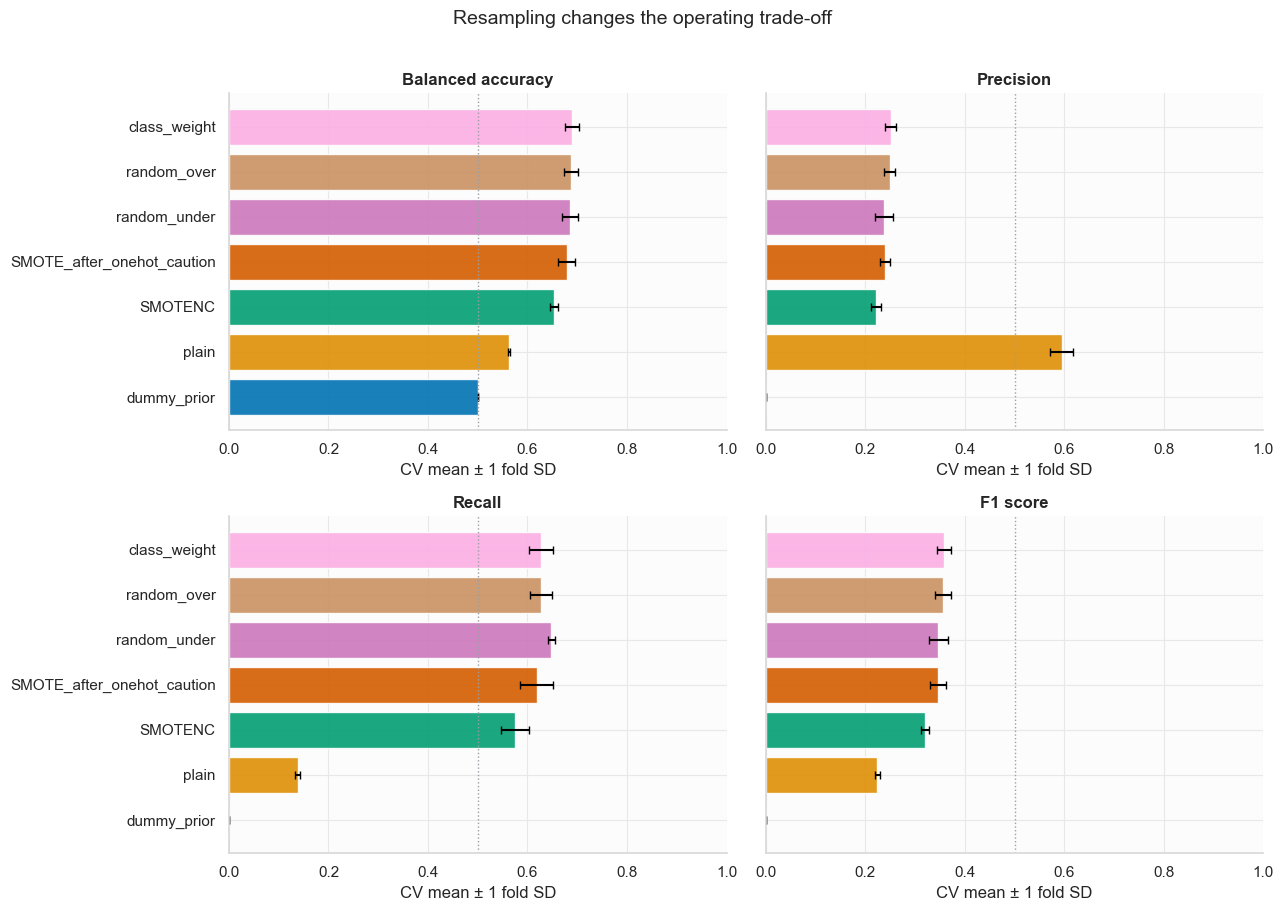

In [24]:
plot_order = cv_comparison.sort_values(
    "balanced_accuracy_mean", ascending=True
).index
metrics_to_plot = ["balanced_accuracy", "precision", "recall", "f1"]
titles = ["Balanced accuracy", "Precision", "Recall", "F1 score"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
colors = sns.color_palette("colorblind", n_colors=len(plot_order))
for ax, metric, title in zip(axes.flat, metrics_to_plot, titles):
    means = cv_comparison.loc[plot_order, f"{metric}_mean"]
    errors = cv_comparison.loc[plot_order, f"{metric}_std"]
    ax.barh(plot_order, means, xerr=errors, color=colors,
            alpha=.9, capsize=3)
    ax.set(title=title, xlabel="CV mean ± 1 fold SD", xlim=(0, 1))
    ax.axvline(.5, color="#9aa0a6", linestyle=":", linewidth=1)
fig.suptitle("Resampling changes the operating trade-off", fontsize=14, y=1.01)
plt.tight_layout()


## Validation behavior and threshold adjustment


In [25]:

def operational_metrics(y_true, probability, threshold=0.5):
    # Return threshold and probability metrics without area-under-curve scores.
    prediction = np.asarray(probability) >= threshold
    tn, fp, fn, tp = confusion_matrix(
        y_true, prediction, labels=[0, 1]
    ).ravel()
    return {
        "log_loss": log_loss(y_true, probability),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
        "cost": float(fp + 5 * fn),
    }

# Choose the threshold from out-of-fold development predictions. The validation
# set remains independent evidence rather than being used both to tune and report.
oof_probability = cross_val_predict(
    clone(candidates["plain"]), X_dev, y_dev, cv=cv,
    method="predict_proba", n_jobs=-1,
)[:, 1]
threshold_candidates = threshold_table(y_dev, oof_probability)
selected = threshold_candidates.sort_values(["cost", "threshold"]).iloc[0]
selected_threshold = float(selected["threshold"])
print(f"OOF development cost-selected threshold: {selected_threshold:.2f}")

validation_rows = []
fitted = {}
for name in ["dummy_prior", "plain", "class_weight", "random_over"]:
    fitted[name] = candidates[name].fit(X_dev, y_dev)
    probability = fitted[name].predict_proba(X_val)[:, 1]
    validation_rows.append({"method": name, **operational_metrics(y_val, probability)})
validation_comparison = pd.DataFrame(validation_rows).set_index("method")
display(validation_comparison.round(4))

plain_probability = fitted["plain"].predict_proba(X_val)[:, 1]
display(pd.DataFrame({
    "plain@0.5": operational_metrics(y_val, plain_probability, .5),
    "plain@OOF-selected": operational_metrics(
        y_val, plain_probability, selected_threshold),
}).T.round(4))


OOF development cost-selected threshold: 0.17


,log_loss,precision,recall,specificity,cost
method,,,,,
dummy_prior,0.3609,0.0000,0.0000,1.0000,2340.0
plain,0.3029,0.6148,0.1603,0.9867,2012.0
class_weight,0.5657,0.2515,0.6218,0.7548,1751.0
random_over,0.5667,0.2496,0.6197,0.7531,1762.0


,log_loss,precision,recall,specificity,cost
plain@0.5,0.3029,0.6148,0.1603,0.9867,2012.0
plain@OOF-selected,0.3029,0.3931,0.5150,0.8947,1507.0


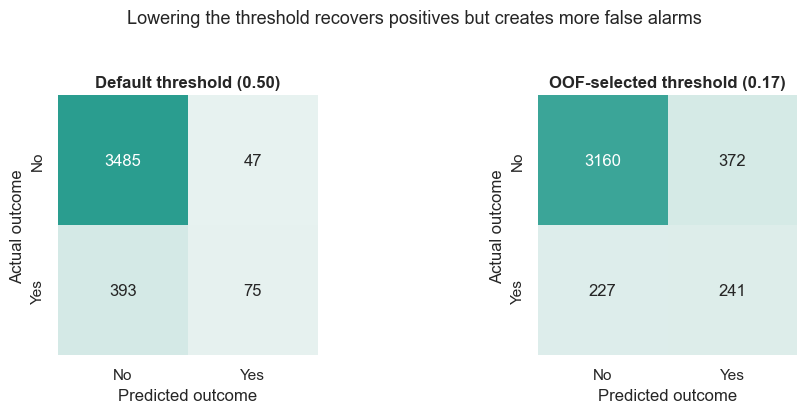

In [26]:
validation_predictions = {
    "Default threshold (0.50)": plain_probability >= 0.50,
    f"OOF-selected threshold ({selected_threshold:.2f})":
        plain_probability >= selected_threshold,
}
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
vmax = max(confusion_matrix(y_val, pred, labels=[0, 1]).max()
           for pred in validation_predictions.values())
for ax, (title, prediction) in zip(axes, validation_predictions.items()):
    matrix = confusion_matrix(y_val, prediction, labels=[0, 1])
    sns.heatmap(matrix, annot=True, fmt="d", cmap=sns.light_palette(BRAND_COLOR, as_cmap=True), cbar=False,
                vmin=0, vmax=vmax, square=True, ax=ax,
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    ax.set(title=title, xlabel="Predicted outcome", ylabel="Actual outcome")
fig.suptitle("Lowering the threshold recovers positives but creates more false alarms",
             fontsize=13, y=1.03)
plt.tight_layout()


### Reading the threshold result correctly

The false-negative cost of 5 and false-positive cost of 1 are teaching assumptions, not facts
learned from the dataset. In a real deployment, replace them with validated economic or clinical
consequences and include capacity constraints. The OOF-selected threshold is evaluated once on
validation; repeatedly revisiting it after seeing validation performance would gradually turn the
validation set into training data.


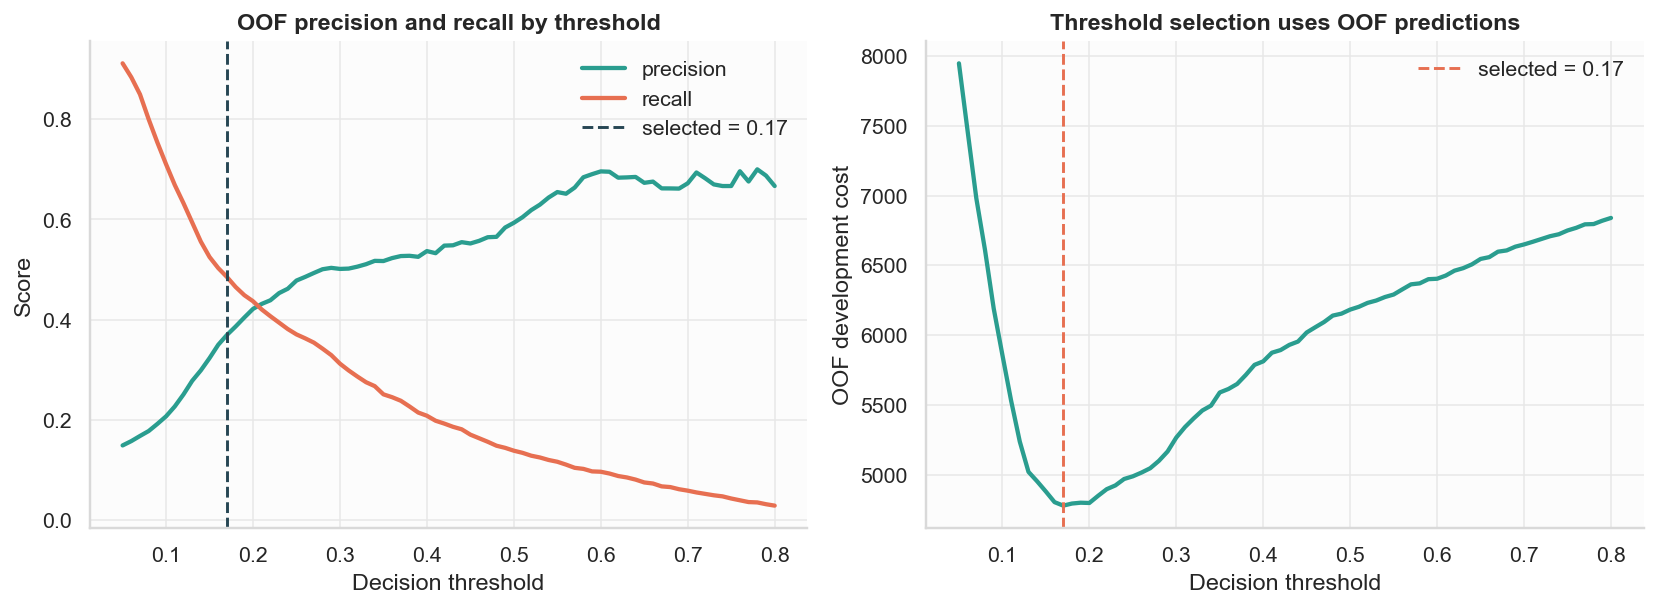

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=140)
axes[0].plot(threshold_candidates["threshold"], threshold_candidates["precision"],
             label="precision", color=BRAND_COLOR, linewidth=2.2)
axes[0].plot(threshold_candidates["threshold"], threshold_candidates["recall"],
             label="recall", color=ACCENT_COLOR, linewidth=2.2)
axes[0].axvline(selected_threshold, color="#264653", linestyle="--",
                label=f"selected = {selected_threshold:.2f}")
axes[0].legend(frameon=False)
axes[0].set(xlabel="Decision threshold", ylabel="Score",
            title="OOF precision and recall by threshold")

axes[1].plot(threshold_candidates["threshold"], threshold_candidates["cost"],
             color=BRAND_COLOR, linewidth=2.2)
axes[1].axvline(selected_threshold, color=ACCENT_COLOR, linestyle="--",
                label=f"selected = {selected_threshold:.2f}")
axes[1].set(xlabel="Decision threshold", ylabel="OOF development cost",
            title="Threshold selection uses OOF predictions")
axes[1].legend(frameon=False)
plt.tight_layout()


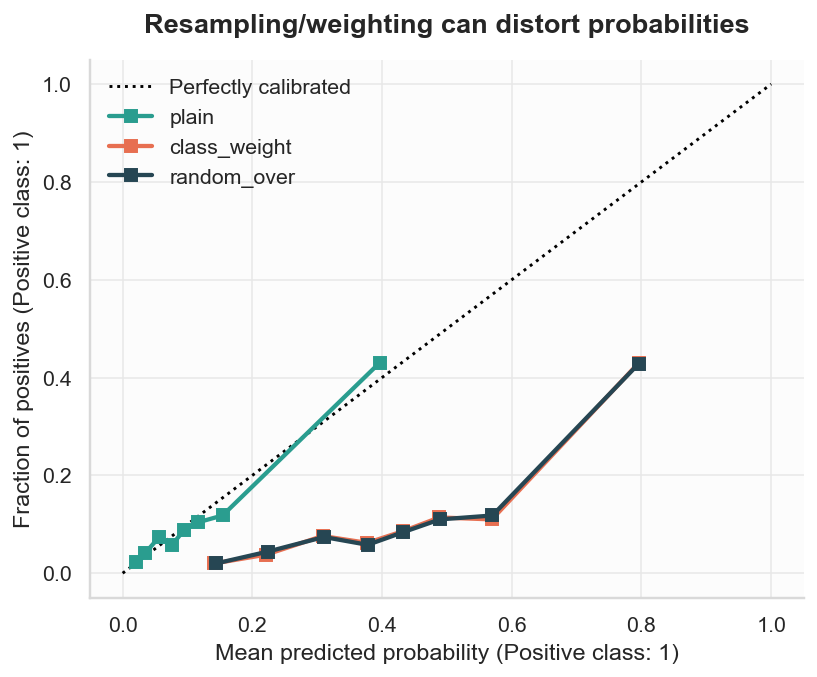

In [28]:
from sklearn.calibration import CalibrationDisplay
fig, ax = plt.subplots(figsize=(6, 5), dpi=140)
calibration_colors = [BRAND_COLOR, ACCENT_COLOR, "#264653"]
for color, name in zip(calibration_colors, ["plain", "class_weight", "random_over"]):
    p = fitted[name].predict_proba(X_val)[:, 1]
    display_curve = CalibrationDisplay.from_predictions(
        y_val, p, n_bins=8, strategy="quantile", name=name, ax=ax
    )
    display_curve.line_.set_color(color)
    display_curve.line_.set_linewidth(2.2)
ax.set_title("Resampling/weighting can distort probabilities", pad=14, fontsize=14, fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()


### What this experiment establishes—and what it does not

- **Classification:** precision, recall, F1, and balanced accuracy depend on a threshold. They
  expose the operational trade-off directly and should be interpreted with class prevalence.
- **Probability quality:** log loss and calibration diagnose whether probabilities can support
  expected-value decisions. Resampling can improve recall while harming probability quality.
- **Uncertainty:** fold standard deviations describe split sensitivity, not a formal confidence
  interval. Repeated or nested CV is appropriate when selection uncertainty matters.
- **Scope:** this is predictive evaluation under an i.i.d. stratified split. It does not estimate
  the causal effect of calling a customer, and the source data cannot support grouped or temporal
  validation because stable customer IDs and complete timestamps are absent.

For deployment, log the dataset hash, split seed, package versions, candidate parameters, fold-level
scores, selected threshold, cost assumptions, and the serialized end-to-end pipeline. Monitor both
score calibration and the operational precision/recall trade-off as prevalence changes.


**When not to synthesize:** avoid SMOTE when neighborhoods are not meaningful, minority data
contain label noise, constraints can be violated, categories have high cardinality, temporal
order matters, or calibrated probabilities are central and recalibration data are scarce.
Threshold adjustment is often the simplest operational intervention when ranking is already good.

## Common mistakes and leakage warnings

- Resampling once before CV or before the train/validation split.
- Applying ordinary SMOTE to raw ordinal category codes.
- Comparing recall at 0.5 while ignoring precision and calibration.
- Assuming the balanced training distribution is the deployment prevalence.
- Tuning sampling ratio and threshold on the test set.

## Exercises

1. Vary `sampling_strategy` and plot balanced accuracy versus log loss with fold-level uncertainty.
2. Calibrate the class-weighted model using nested CV or a dedicated calibration split; compare
   reliability curves, log loss, and Brier score before and after calibration.
3. Add bootstrap confidence intervals for validation recall, precision, and business cost.
4. **Challenge:** design a repeated nested-CV experiment comparing threshold tuning with SMOTENC,
   including uncertainty and a fixed business cost.

## Summary

Class weighting and resampling alter the fitting objective; threshold adjustment alters only the
decision rule. None is automatically best. Samplers belong inside CV pipelines, and mixed data
require categorical-aware synthesis when synthesis is justified at all.

## References

- [imbalanced-learn pipeline](https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.Pipeline.html)
- [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)
- [SMOTENC](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTENC.html)
